# 基于经典网络架构训练图像分类模型

## 数据预处理部分：
- 数据增强：torchvision中transforms模块自带功能，比较实用
- 数据预处理：torchvision中transforms也帮我们实现好了，直接调用即可
- DataLoader模块直接读取batch数据

# 网络模块设置：
- 加载预训练模型，torchvision中有很多经典网络架构，调用起来十分方便，并且可以用人家训练好的权重参数来继续训练，也就是所谓的迁移学习。
- 需要注意的是别人训练好的任务跟咱们的可不是完全一样，需要把最后的head层改一改，一般也就是**最后的全连接层**，改成咱们自己的任务。
- 训练时可以全部重头训练，也可以只训练最后咱们任务的层，因为前几层都是做特征提取的，本质任务目标是一致的。

## 网络模型保存与测试
- 模型保存的时候可以带有选择性，例如在验证集中如果当前效果好则保存
- 读取模型进行实际测试

In [1]:
import os
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import torch
from torch import nn
import torch.optim as optim
import torchvision
#pip install torchvision
#transforms一般用于数据增强，models负责调用模型【resnet】，datasets表示以文件夹当做目录结构读取数据
from torchvision import transforms, models, datasets
#https://pytorch.org/docs/stable/torchvision/index.html
import imageio
import time
import warnings
warnings.filterwarnings("ignore")
import random
import sys
import copy
import json
from PIL import Image

## 数据读取与预训练操作

In [2]:
data_dir = 'data/Oracle2'
train_dir = data_dir + '/train'
valid_dir = data_dir + '/valid'

## 制作好数据源
- data_transforms中指定了所有**图像预处理**操作
- ImageFolder假设所有的文件按**文件夹**保存好，每个文件夹下面存贮同一类别的图片，文件夹的名字为分类的名字

数据增强可以是指通过旋转、缩放等操作使得数据增多的操作，适用于样本数据少的项目

In [3]:
# 自定义补边成正方形的函数（核心：保住甲骨文所有笔画，不裁剪）
def pad_to_square(img):
    w, h = img.size
    max_side = max(w, h)
    # 计算上下左右需要补的边（居中补，避免偏移）
    pad_left = (max_side - w) // 2
    pad_right = max_side - w - pad_left
    pad_top = (max_side - h) // 2
    pad_bottom = max_side - h - pad_top
    # 补白色边（适配甲骨文浅色背景，避免干扰）
    return transforms.Pad((pad_left, pad_top, pad_right, pad_bottom), fill=255)(img)

# 针对甲骨文数据集优化的transforms
data_transforms = {
    'train':
        transforms.Compose([
            # 第一步：按中位数比例缩放（短边对齐，保字形不变形）
            transforms.Resize((96, 64)),  # 匹配数据集中位数96×64，先按原比例缩放
            # 第二步：补边成正方形（适配模型输入，不切笔画）
            pad_to_square,
            # 数据增强（适配甲骨文特点，减少无效增强）
            transforms.RandomRotation(15),  # 甲骨文旋转幅度不宜过大，从45°降到15°，-15°到15°随机
            transforms.RandomHorizontalFlip(p=0.0),  # 甲骨文无左右翻转意义，关闭
            transforms.RandomVerticalFlip(p=0.0),    # 甲骨文无上下翻转意义，关闭
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.0, hue=0.0), 
            # 仅保留亮度/对比度增强，色相/饱和度对甲骨文无意义
            transforms.RandomGrayscale(p=0.025),    # 灰度增强保留（少量）
            transforms.ToTensor(),
            #拿别人千万级别的数据项目的均值标准差做，使得结果更稳一些，三个参数分别是R-G-B
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) #均值，标准差
        ]),
    'valid':
        transforms.Compose([
            # valid集和train集保持一致的缩放逻辑，避免尺寸不匹配
            transforms.Resize((96, 64)),  # 同train，按中位数比例缩放
            pad_to_square,                # 补边成正方形
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
}

In [4]:
batch_size = 128

#把 data_dir/train 文件夹里的图片用 data_transforms['train'] 的变换方式打包成训练集，把 data_dir/valid 文件夹里的图片用 data_transforms['valid'] 的变换方式打包成验证集，最后把这两个数据集存到 image_datasets 这个字典里。
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'valid']}
#为训练集和验证集分别创建数据加载器：训练集和验证集都按 batch_size 的大小分批加载，并且都打乱顺序，最后把这两个加载器存到 dataloaders 字典里。
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size, shuffle=True) for x in ['train', 'valid']}
#数了数训练集和验证集里各有多少张图片，把这两个数字存到 `dataset_sizes` 字典里。
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid']}
#从训练集里提取出所有甲骨文字类别的名字列表，存到 class_names 里。
class_names = image_datasets['train'].classes

In [5]:
class_names #索引所对应的类别顺序会有所改变

['万',
 '丘',
 '丙',
 '丧',
 '乘',
 '亦',
 '人',
 '今',
 '介',
 '从',
 '令',
 '以',
 '伊',
 '何',
 '余',
 '允',
 '元',
 '兄',
 '光',
 '兔',
 '入',
 '凤',
 '化',
 '北',
 '印',
 '及',
 '取',
 '口',
 '吉',
 '囚',
 '夫',
 '央',
 '宗',
 '宾',
 '尞',
 '巳',
 '帽',
 '并',
 '彘',
 '往',
 '御',
 '微',
 '旨',
 '昃',
 '木',
 '朿',
 '涎',
 '灾',
 '焦',
 '爽',
 '牝',
 '牡',
 '牧',
 '生',
 '田',
 '疑',
 '祝',
 '福',
 '立',
 '羊',
 '羌',
 '翌',
 '翼',
 '老',
 '艰',
 '艺',
 '若',
 '莫',
 '获',
 '衣',
 '逆',
 '门',
 '降',
 '陟',
 '雍',
 '鹿']

In [6]:
image_datasets

{'train': Dataset ImageFolder
     Number of datapoints: 32466
     Root location: data/Oracle2\train
     StandardTransform
 Transform: Compose(
                Resize(size=(96, 64), interpolation=bilinear, max_size=None, antialias=True)
                <function pad_to_square at 0x0000024F8CA4B060>
                RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
                RandomHorizontalFlip(p=0.0)
                RandomVerticalFlip(p=0.0)
                ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=None, hue=None)
                RandomGrayscale(p=0.025)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ),
 'valid': Dataset ImageFolder
     Number of datapoints: 8151
     Root location: data/Oracle2\valid
     StandardTransform
 Transform: Compose(
                Resize(size=(96, 64), interpolation=bilinear, max_size=None, antialias=True)
            

In [7]:
dataloaders

{'train': <torch.utils.data.dataloader.DataLoader at 0x24fae20b710>,
 'valid': <torch.utils.data.dataloader.DataLoader at 0x24fae20b170>}

In [8]:
dataset_sizes

{'train': 32466, 'valid': 8151}

## 读取标签对应的实际名字【比如1：“北”，可以读取一个json文件，现在这个暂时用不上】

## 加载models中提供的模型，并且直接用训练的好权重当做初始化参数
- 第一次执行需要下载，可能会比较慢

In [9]:
model_name = 'resnet34'  #可选的比较多 ['resnet', 'alexnet', 'vgg', 'squeezenet', 'densenet', 'inception']
num_classes = 76
#是否用人家训练好的特征来做
feature_extract = True  #都用人家特征，咱先不更新

In [10]:
# 是否用GPU训练
train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

CUDA is available!  Training on GPU ...


### 模型参数要不要更新
- 有时候用人家模型，就一直用了，更不更新咱们可以自己定

### 迁移学习指的是站在巨人的肩膀上
- 小数据，冻住大部分权重参数，只修改输出层
- 中数据，冻住一些权重参数，领着模型上上道
- 大数据，可以不冻住权重参数，只作为初始化

In [11]:
model_ft = models.resnet34() #18层的能快点，条件好点的也可以选152
model_ft

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [12]:
def set_parameter_requires_grad(model, feature_extracting):
    if feature_extracting:
        for param in model.parameters():
            #停止计算反向传播的梯度 -> 不更新权重参数
            param.requires_grad = False

## 把模型输出层改成自己的

In [13]:
def initialize_model(model_name, num_classes, feature_extract, use_pretrained=True):
    
    # 1. 创建模型结构
    model_ft = models.resnet34(pretrained=False)
    set_parameter_requires_grad(model_ft, feature_extract)
    
    # 2. 【关键】先加载本地预训练权重（此时fc还是1000类）
    if use_pretrained:
        pretrained_path = r"D:\唐宇迪\Pytorch篇笔记\代码\resnet34-333f7ec4.pth"
        state_dict = torch.load(pretrained_path, map_location='cpu')
        
        # 加载权重（此时fc层形状匹配，能成功加载）
        model_ft.load_state_dict(state_dict, strict=False)
        print(f"成功加载本地预训练模型: {pretrained_path}")
    
    # 3. 【关键】再替换全连接层为自己的类别数
    # 这样只有最后一层是随机的，前面都是预训练好的
    num_ftrs = model_ft.fc.in_features
    model_ft.fc = nn.Linear(num_ftrs, num_classes)
    
    input_size = 224
    
    return model_ft, input_size

## 设置哪些层

In [14]:
model_ft, input_size = initialize_model(model_name, num_classes, feature_extract, use_pretrained=True)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_ft = model_ft.to(device)

# 模型保存，名字自己起【训练完之后最好的模型结果】
# 保存内容包含：模型架构图(结构定义)、w(权重参数)、b(偏置参数)等完整状态
filename='best_oracle.pt'

# 是否训练所有层
params_to_update = model_ft.parameters()
# 默认获取模型所有可训练参数(生成器对象)，用于后续传递给优化器
print("Params to learn:")
# 打印即将参与训练的参数名称，便于调试和验证配置正确性

if feature_extract:
    params_to_update = []
    for name,param in model_ft.named_parameters():
        # 检查参数是否需要梯度计算(被冻结的层requires_grad=False)
        if param.requires_grad == True:
            params_to_update.append(param)
            print("\t",name)
else:
    # 当feature_extract=False时，执行完整微调(fine-tuning)
    for name,param in model_ft.named_parameters():
        # 此时所有层默认都是可训练的(除非手动冻结)
        if param.requires_grad == True:
            print("\t",name)

成功加载本地预训练模型: D:\唐宇迪\Pytorch篇笔记\代码\resnet34-333f7ec4.pth
Params to learn:
	 fc.weight
	 fc.bias


In [15]:
model_ft

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

- lr = 1e-1    # 0.1   (较大，适合简单问题或微调初期)
- lr = 1e-2    # 0.01  (常用默认值)
- lr = 1e-3    # 0.001 (常用，适合预训练模型微调)
- lr = 1e-4    # 0.0001 (较小，适合精细调整)
- lr = 5e-5    # 0.00005 (BERT等Transformer常用)

In [16]:
# 优化器设置
optimizer_ft = optim.Adam(params_to_update, lr=1e-2) #要训练啥参数，你来定，lr是0.01
scheduler = optim.lr_scheduler.StepLR(optimizer_ft, step_size=10, gamma=0.1) #学习率每10个epoch【step_size】衰减成原来的1/10【gamma】
criterion = nn.CrossEntropyLoss()

## 训练模块

In [17]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=25, filename='best_oracle.pt'):
    #咱们要算时间的
    since = time.time()
    #也要记录最好的那一次,准确率
    best_acc = 0
    #模型也得放到你的CPU或者GPU
    model.to(device)
    #训练过程中打印一堆损失和指标
    val_acc_history = []
    train_acc_history = []
    train_losses = []
    valid_losses = []
    #学习率
    LRs = [optimizer.param_groups[0]['lr']]
    #最好的那次模型，后续会变的，先初始化
    best_model_wts = copy.deepcopy(model.state_dict())
    #一个个epoch来遍历
    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # 训练和验证
        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()  # 训练
            else:
                model.eval()   # 验证
        
            running_loss = 0.0
            running_corrects = 0
        
            # 把数据都取个遍
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device) #放到你的CPU或GPU
                labels = labels.to(device)
        
                # 清零
                optimizer.zero_grad()
                # 只有训练的时候计算和更新梯度
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                # 训练阶段更新权重
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

                # 计算损失
                running_loss += loss.item() * inputs.size(0) #0表示batch那个维度
                running_corrects += torch.sum(preds == labels.data) #预测结果最大的和真实值是否一致


            epoch_loss = running_loss / len(dataloaders[phase].dataset) #算平均
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)
            
            time_elapsed = time.time() - since #一个epoch我浪费了多少时间
            print('Time elapsed {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))


            # 得到最好那次的模型
            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                state = {
                    'state_dict': model.state_dict(), #字典里key就是各层的名字，值就是训练好的权重
                    'best_acc': best_acc,
                    'optimizer' : optimizer.state_dict(),
                }
                torch.save(state, filename)
            if phase == 'valid':
                val_acc_history.append(epoch_acc)
                valid_losses.append(epoch_loss)
                #scheduler.step(epoch_loss) #学习率衰减
            if phase == 'train':
                train_acc_history.append(epoch_acc)
                train_losses.append(epoch_loss)

        print('Optimizer learning rate : {:.7f}'.format(optimizer.param_groups[0]['lr']))
        LRs.append(optimizer.param_groups[0]['lr'])
        print()
        scheduler.step() #学习率衰减

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))
    
    # 训练完后用最好的一次当做模型最终的结果,等着一会测试
    model.load_state_dict(best_model_wts)
    return model, val_acc_history, train_acc_history, valid_losses, train_losses, LRs

## 开始训练
- 我们现在只训练了输出层

In [18]:
model_ft, val_acc_history, train_acc_history, valid_losses, train_losses, LRs = train_model(model_ft,
                                                                                            dataloaders,
                                                                                            criterion,
                                                                                            optimizer_ft,
                                                                                            num_epochs=25,
                                                                                            filename='best_oracle.pt')

Epoch 0/24
----------


KeyboardInterrupt: 

## 再继续训练所有层
- 经过25轮训练后，最后一层fc已经有了自己的初步判断，这时候可以解冻上面的所有层再进行一次训练

In [19]:
for param in model_ft.parameters():
    param.requires_grad = True

# 再继续训练所有的参数，学习率调小一点
optimizer_ft = optim.Adam(model_ft.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

# 损失函数
criterion = nn.CrossEntropyLoss()

In [20]:
# 加载之前训练好的权重参数
checkpoint = torch.load(filename)  # 加载最好的那次模型
best_acc = checkpoint['best_acc']
model_ft.load_state_dict(checkpoint['state_dict'])  #用checkpoint里面的模型参数去替换model_ft里的权重参数

<All keys matched successfully>

In [21]:
model_ft, val_acc_history, train_acc_history, valid_losses, train_losses, LRs = train_model(model_ft,
                                                                                            dataloaders,
                                                                                            criterion,
                                                                                            optimizer_ft,
                                                                                            num_epochs=25)

Epoch 0/24
----------


KeyboardInterrupt: 

## 【本地】加载训练好的模型

In [22]:
# 加载自己训练的模型时，不需要再加载ImageNet权重
model_ft, input_size = initialize_model(model_name, 76, feature_extract, use_pretrained=False)

# GPU模式
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_ft = model_ft.to(device)

# 加载自己训练的权重
filename = 'best_oracle.pt'
checkpoint = torch.load(filename, map_location=device)
model_ft.load_state_dict(checkpoint['state_dict'])
best_acc = checkpoint['best_acc']

print(f"✅ 成功加载训练好的模型: {filename}")
print(f"🎯 验证集最佳准确率: {best_acc:.4f}")

✅ 成功加载训练好的模型: best_oracle.pt
🎯 验证集最佳准确率: 0.9390


## 测试数据预处理
- 测试数据处理方法需要跟训练时一样才可以
- crop操作的目的是保证输入的大小是一致的
- 标准化操作也是必须的，用跟训练数据相同的mean和std，但是需要注意一点训练数据是在0-1上进行标准化，所以测试数据也需要先归一化
- 最后一点，Pytorch中颜色通道是第一个维度，跟很多工具包都不一样，需要转换

In [29]:
# 得到一个batch的测试数据
dataiter = iter(dataloaders['valid'])
images, labels = next(dataiter)

model_ft.eval()

if train_on_gpu:
    output = model_ft(images.cuda())
else:
    output = model_ft(images)

output表示对一个batch中每一个数据得到其属于各个类别的可能性

In [30]:
output.shape  ##第一个参数是batch

torch.Size([128, 76])

## 得到概率最大的那个

In [31]:
_, preds_tensor = torch.max(output, 1)

#PyTorch不认识字符串，它内部会把你的文件夹名（比如"cat"、"dog"）自动映射成数字编号
preds = np.squeeze(preds_tensor.numpy()) if not train_on_gpu else np.squeeze(preds_tensor.cpu().numpy())
preds

array([62, 62, 28,  7, 37,  7, 71, 39, 33,  7, 54,  7, 45,  3,  7, 62,  2,
       44,  7, 27, 28, 59, 49, 44,  2, 44, 39, 15, 28, 54, 40, 62, 59, 20,
       34, 62, 44, 62,  2, 56,  2, 33, 25, 15, 27, 44, 27, 32,  0, 10, 26,
       10, 34, 28, 26, 54,  2, 54,  7,  7,  6,  7, 27, 13, 28,  5,  7, 44,
       44, 15,  7, 58, 45,  2,  7, 39, 21, 54, 28, 45, 10, 40, 68, 68, 44,
       15,  7, 15, 62, 44, 62, 29,  7, 73,  7, 62, 33, 39, 66, 62,  7,  7,
        7, 44,  7, 44, 54, 28, 33, 39, 25, 62,  9, 33, 66, 60, 42, 62, 60,
        0, 62, 33, 45, 54, 39,  7, 28, 10])

## 展示预测结果

In [32]:
images.shape

torch.Size([128, 3, 96, 96])

In [33]:
def im_convert(tensor):
    """展示数据 - 支持单张或一批图片"""
    image = tensor.to("cpu").clone().detach()
    
    # 如果是一批图片，只取第一张
    if len(image.shape) == 4:  # [128,3,96,96]
        image = image[0]  # 变成[3,96,96]
    
    image = image.numpy()

    # torch -> 3*96*96【channel在最前0这个位置，一般顺序是0、1、2】，这个操作就是把channel挪到最后，因为一般只有torch才用这个结构
    image = image.transpose(1, 2, 0)  # [3,96,96] → [96,96,3]
    image = image * np.array((0.229, 0.224, 0.225)) + np.array((0.485, 0.456, 0.406))
    image = image.clip(0, 1)
    
    return image

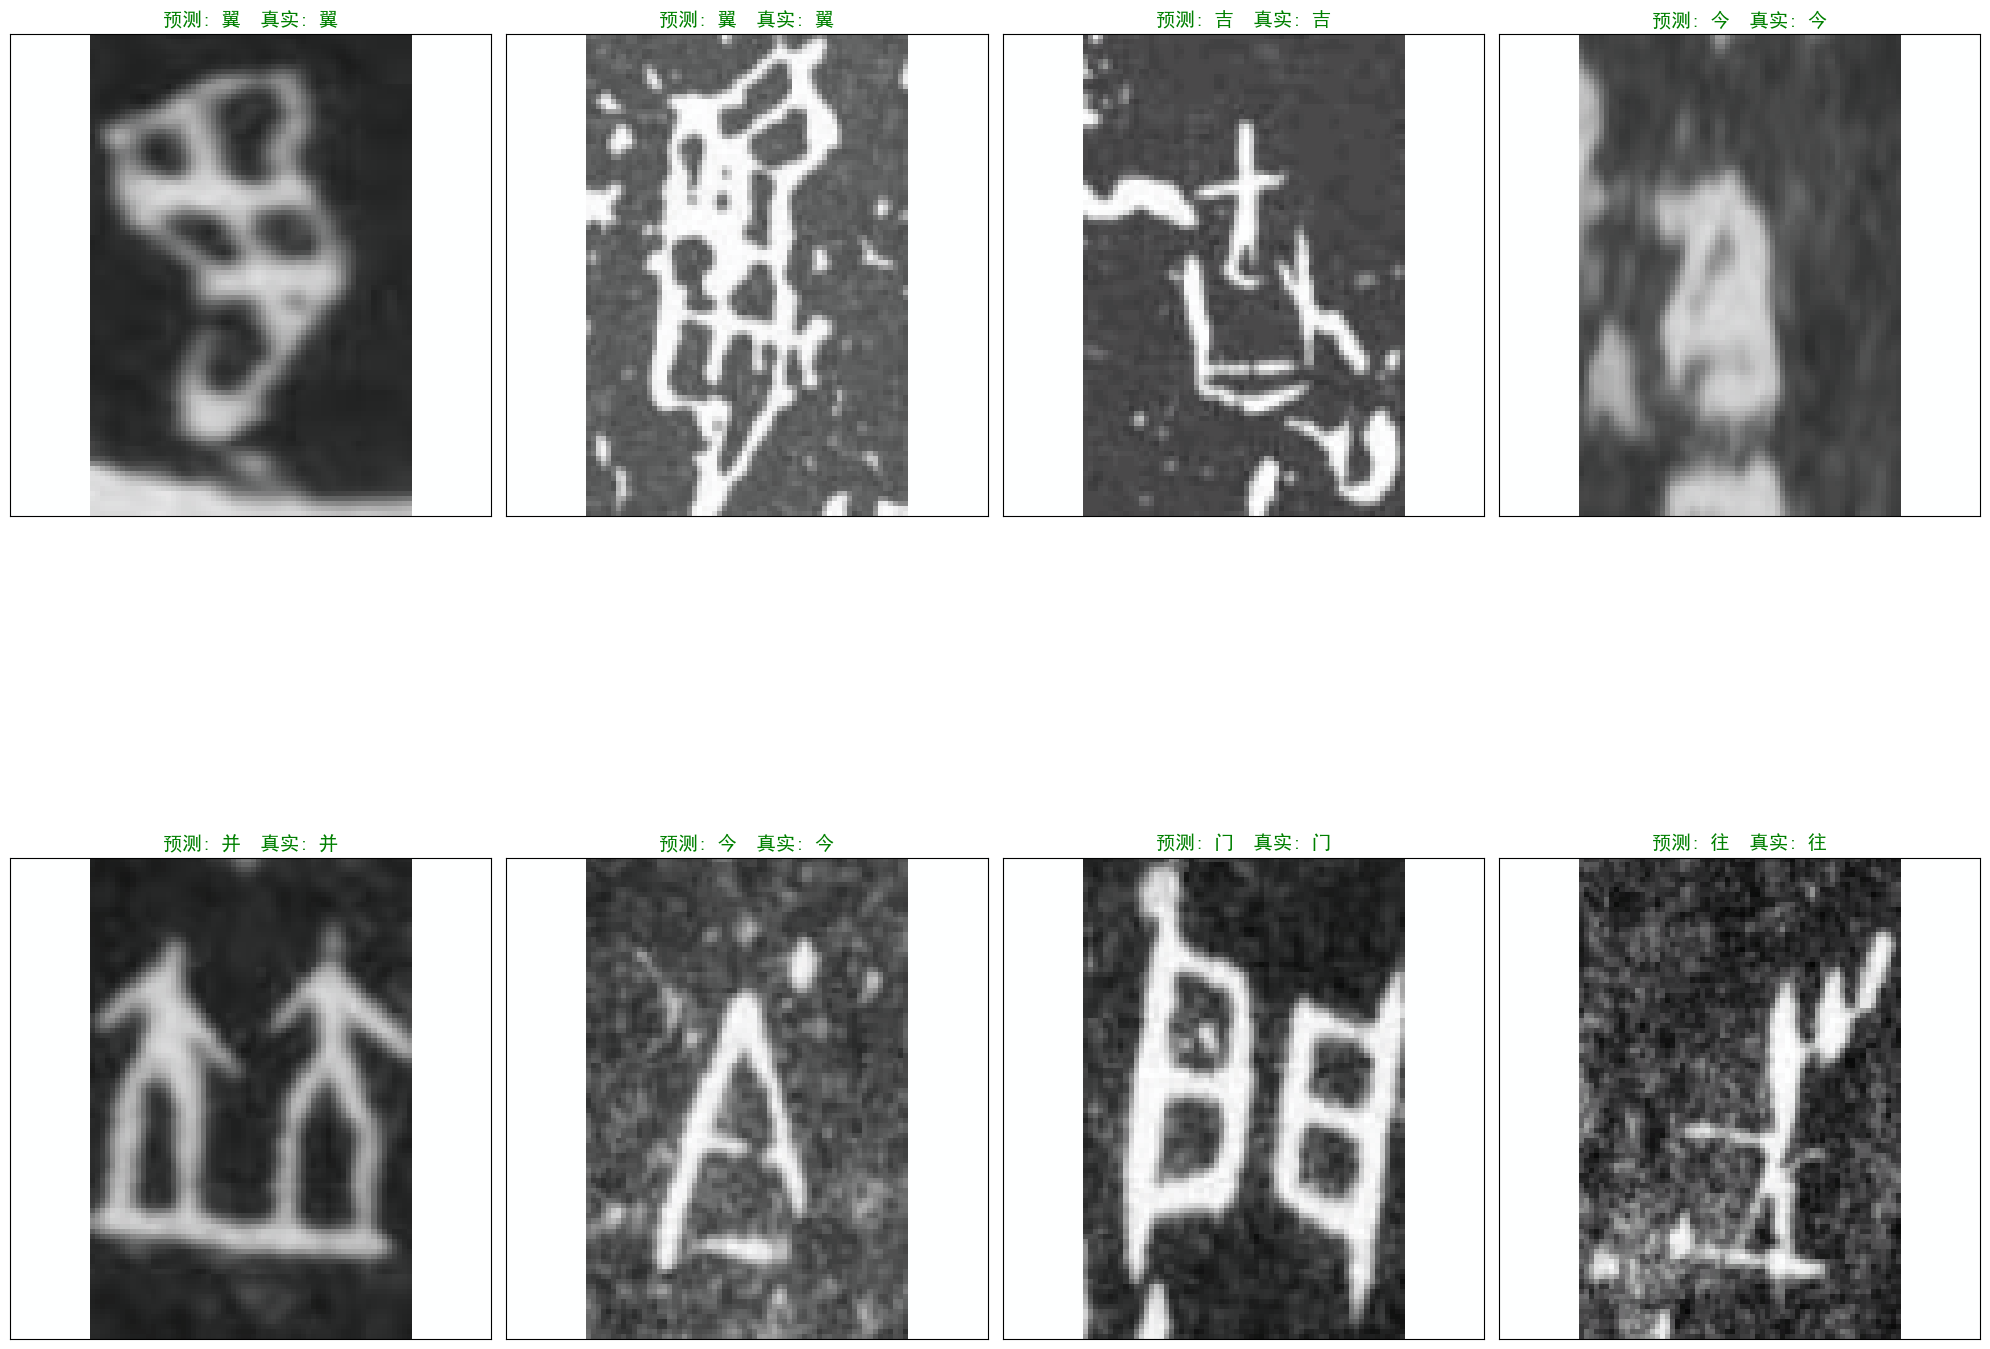

In [34]:
import matplotlib.pyplot as plt
import os

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 自动获取类别映射
train_path = r'data/Oracle2/train'  # 改成你的路径
class_names = sorted(os.listdir(train_path))
idx_to_name = {i: name for i, name in enumerate(class_names)}

# 画图
fig = plt.figure(figsize=(20, 20))
columns = 4
rows = 2

for idx in range(columns * rows):
    ax = fig.add_subplot(rows, columns, idx + 1, xticks=[], yticks=[])
    plt.imshow(im_convert(images[idx]))
    
    # 数字转中文
    pred_name = idx_to_name[preds[idx]]
    true_name = idx_to_name[labels[idx].item()]
    
    ax.set_title(
        f"预测: {pred_name}  真实: {true_name}",
        color="green" if preds[idx] == labels[idx].item() else "red",
        fontsize=14
    )

plt.tight_layout()
plt.show()